BUSINESS OBJECTIVE


This notebook focuses on forecasting future ITSM incident volumes using time-series forecasting techniques.

Forecasting helps organizations:

- predict workload growth
- allocate operational resources
- improve SLA planning
- optimize staffing requirements
- identify seasonal incident trends

The notebook uses Facebook Prophet and ARIMA models for incident volume forecasting.

IMPORT LIBRARIES

In [5]:
%pip install prophet
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

LOAD CLEAN DATASET

In [7]:
import os

print(os.getcwd())

C:\Projects_Dm\ITSM_project\Notebooks


In [8]:
df = pd.read_csv(
    r"C:\Projects_Dm\ITSM_project\data\processed\itsm_cleaned.csv",
    low_memory=False
)

print("successfully loaded dataset")

successfully loaded dataset


DATETIME CONVERSION

In [9]:
df['Open_Time'] = pd.to_datetime(
    df['Open_Time'],
    errors='coerce'
)

INCIDENT TREND PREPARATION



In [10]:
incident_trend = (
    df.groupby(
        df['Open_Time'].dt.date
    )
    .size()
    .reset_index(name='Incident_Count')
)

In [11]:
incident_trend.columns = ['ds', 'y']

VISUALIZE INCIDENT TREND

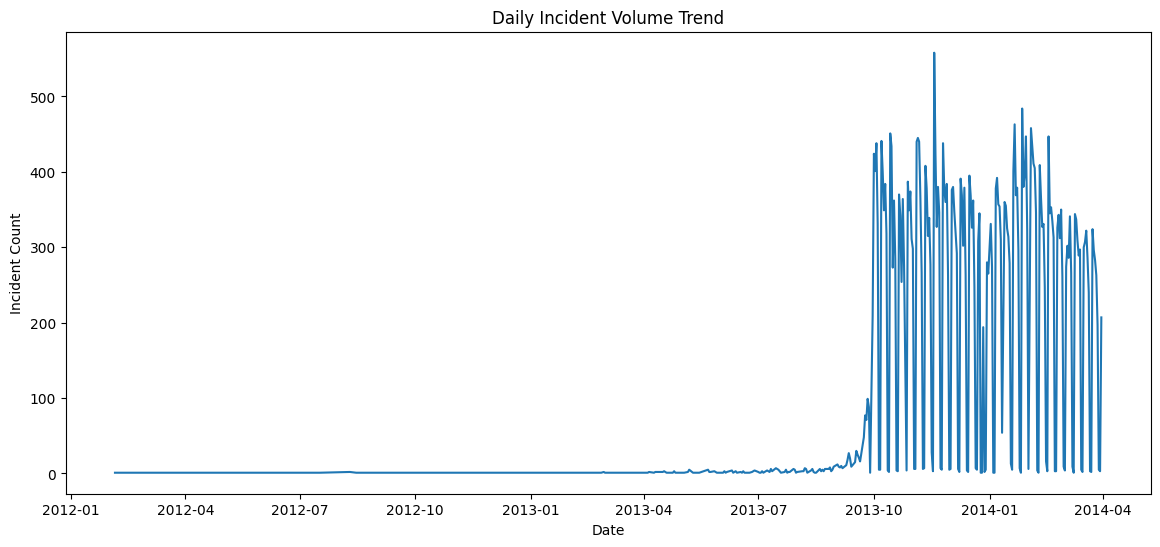

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    incident_trend['ds'],
    incident_trend['y']
)

plt.title("Daily Incident Volume Trend")

plt.xlabel("Date")

plt.ylabel("Incident Count")

plt.show()

TRAIN PROPHET MODEL

In [13]:
prophet_model = Prophet()

prophet_model.fit(incident_trend)

16:05:22 - cmdstanpy - INFO - Chain [1] start processing
16:05:23 - cmdstanpy - INFO - Chain [1] done processing


FUTURE FORECAST

In [15]:
future = prophet_model.make_future_dataframe(
    periods=365
)

forecast = prophet_model.predict(future)

FORECAST VISUALIZATION

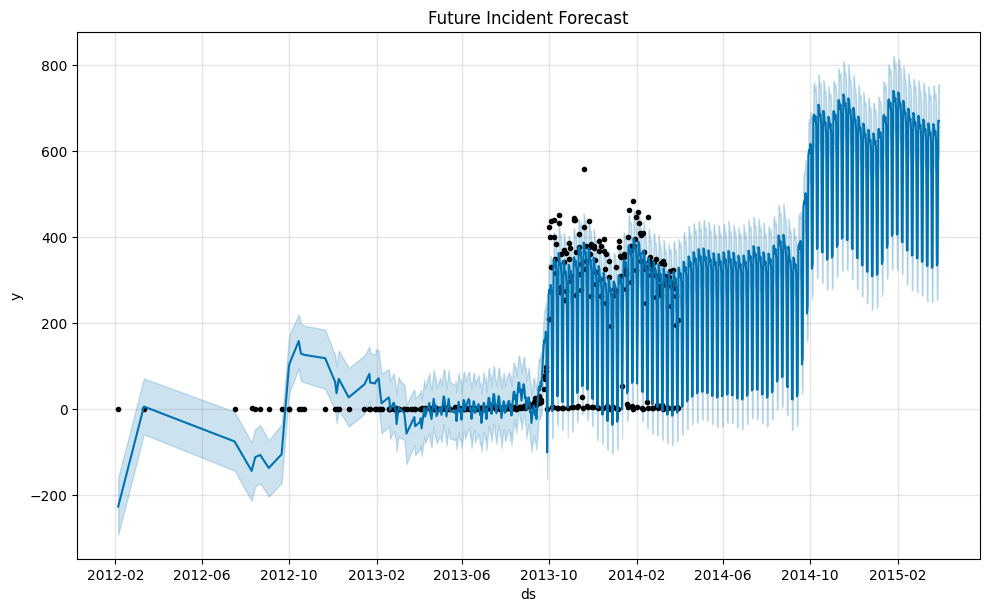

In [16]:
prophet_model.plot(forecast)

plt.title("Future Incident Forecast")

plt.show()

FORECAST COMPONENTS

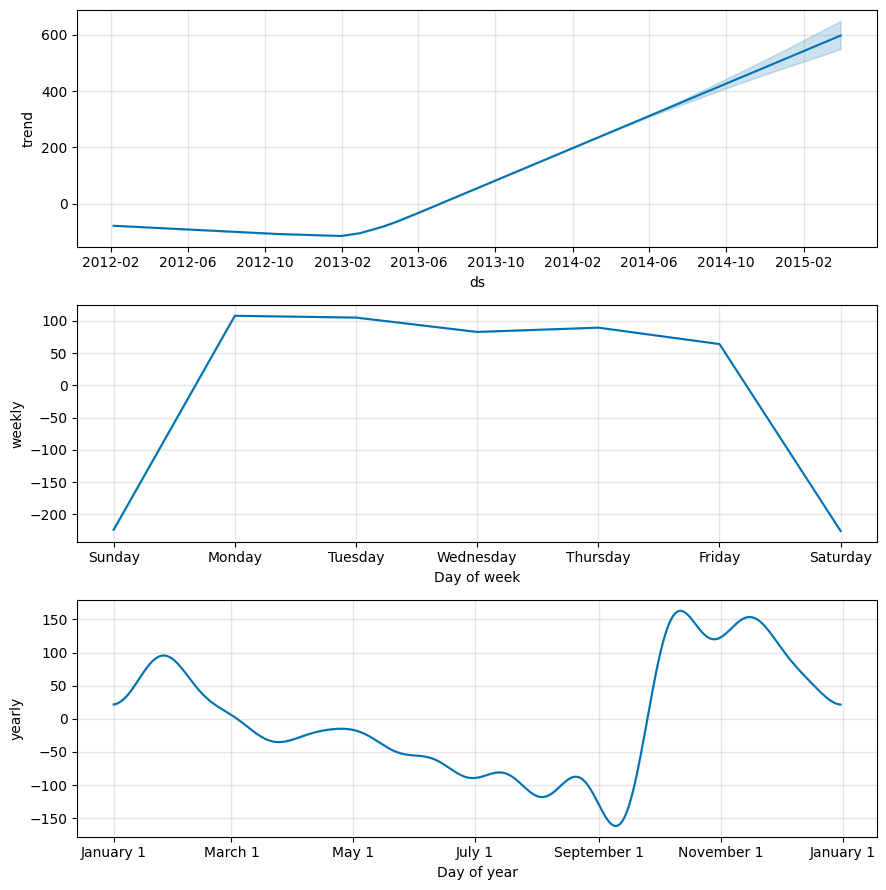

In [17]:
prophet_model.plot_components(forecast)

plt.show()

ARIMA MODEL

In [18]:
ts_data = incident_trend.set_index('ds')['y']

TRAIN ARIMA

In [19]:
arima_model = ARIMA(
    ts_data,
    order=(5,1,0)
)

arima_result = arima_model.fit()

FORECAST

In [20]:
arima_forecast = arima_result.forecast(
    steps=30
)

print(arima_forecast)

327    280.397087
328    242.571113
329    241.705203
330    156.521798
331     29.484938
332     86.326876
333    222.322989
334    238.782356
335    223.472004
336    219.114205
337    131.688527
338     65.853768
339    139.536392
340    216.482275
341    212.676889
342    213.048295
343    196.854087
344    122.575976
345    102.257917
346    167.973791
347    204.032545
348    198.838132
349    204.364944
350    178.388374
351    125.138493
352    131.927154
353    179.508407
354    192.709362
355    192.128762
356    195.352230
Name: predicted_mean, dtype: float64


BUSINESS INSIGHTS


Forecasting analysis identified operational incident growth trends and seasonal workload behavior.

The Prophet model successfully captured long-term incident patterns and can support:

- workforce planning
- SLA optimization
- operational monitoring
- proactive ITSM resource allocation

Forecasting future incident volumes enables ABC Tech to improve service reliability and operational efficiency.





TEST PROPHET IMPORT



In [22]:

from prophet import Prophet

print("Prophet installed successfully")

Prophet installed successfully


In [23]:
prophet_model = Prophet()

prophet_model.fit(incident_trend)

16:06:45 - cmdstanpy - INFO - Chain [1] start processing
16:06:45 - cmdstanpy - INFO - Chain [1] done processing


LOAD DATASET

In [24]:
import pandas as pd

df = pd.read_csv(
    r"C:\Projects_Dm\ITSM_project\data\processed\itsm_cleaned.csv",
    low_memory=False
)

print(df.shape)

df.head()

(45226, 26)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,Open_Year,Open_Month,Open_Day,Open_Hour,Open_Weekday
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,2013-11-04 13:51:00,3.871691e+09,Other,1.0,SD0000007,2012,2,5,13,6
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,2013-12-02 12:36:00,4.354786e+09,Software,1.0,SD0000011,2012,3,12,15,0
2,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,2013-11-14 09:31:00,4.321833e+09,Operator error,1.0,SD0000025,2012,7,17,11,1
3,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,2013-11-08 13:55:00,3.383903e+09,Other,1.0,SD0000029,2012,8,10,11,4
4,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,2013-11-08 13:54:00,3.383437e+09,Other,1.0,SD0000031,2012,8,10,11,4


CONVERT DATETIME

In [25]:
df['Open_Time'] = pd.to_datetime(
    df['Open_Time'],
    errors='coerce'
)

CREATE INCIDENT TREND

In [26]:
incident_trend = (
    df.groupby(
        df['Open_Time'].dt.date
    )
    .size()
    .reset_index(name='Incident_Count')
)

RENAME FOR PROPHET

In [27]:
incident_trend.columns = ['ds', 'y']

incident_trend.head()

,ds,y
0,2012-02-05,1
1,2012-03-12,1
2,2012-07-17,1
3,2012-08-10,2
4,2012-08-15,1


VISUALIZE TREND

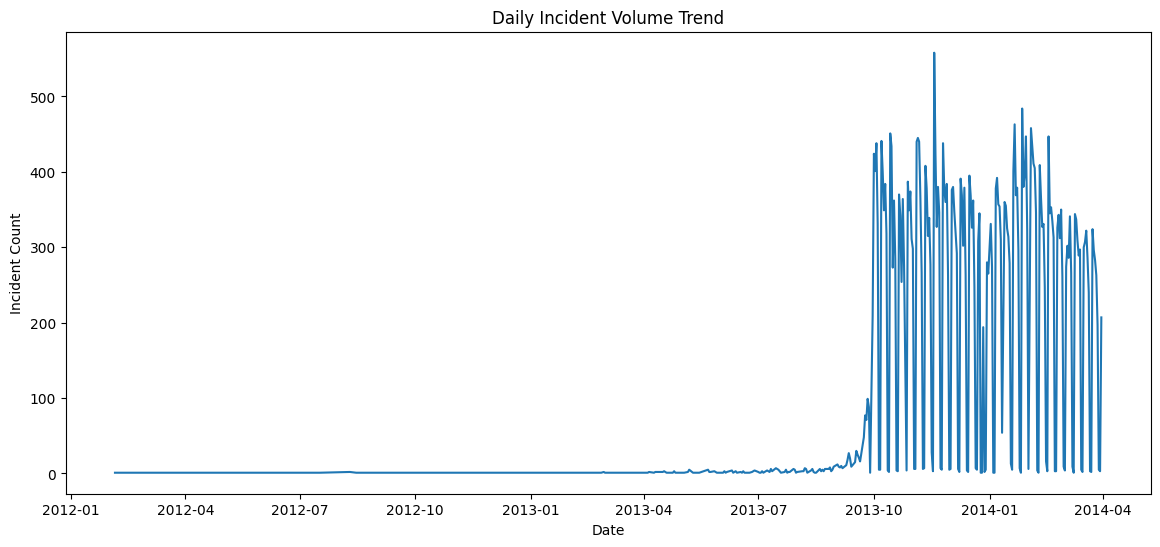

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    incident_trend['ds'],
    incident_trend['y']
)

plt.title("Daily Incident Volume Trend")

plt.xlabel("Date")

plt.ylabel("Incident Count")

plt.show()


TRAIN PROPHET MODEL

In [29]:

from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(incident_trend)

16:07:19 - cmdstanpy - INFO - Chain [1] start processing
16:07:19 - cmdstanpy - INFO - Chain [1] done processing


CREATE FUTURE DATES

Forecast next 365 days.

In [30]:
future = prophet_model.make_future_dataframe(
    periods=365
)

GENERATE FORECAST

In [31]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2012-02-05,-78.030173,-289.177423,-164.443504,-78.030173,-78.030173,-148.286813,-148.286813,-148.286813,-223.962015,-223.962015,-223.962015,75.675202,75.675202,75.675202,0.0,0.0,0.0,-226.316986
1,2012-03-12,-82.127736,-59.397802,76.573328,-82.127736,-82.127736,88.430941,88.430941,88.430941,107.960223,107.960223,107.960223,-19.529282,-19.529282,-19.529282,0.0,0.0,0.0,6.303205
2,2012-07-17,-96.583029,-137.746048,-9.937968,-96.583029,-96.583029,21.723817,21.723817,21.723817,105.195844,105.195844,105.195844,-83.472028,-83.472028,-83.472028,0.0,0.0,0.0,-74.859213
3,2012-08-10,-99.314738,-214.231609,-76.312669,-99.314738,-99.314738,-44.027467,-44.027467,-44.027467,64.135639,64.135639,64.135639,-108.163106,-108.163106,-108.163106,0.0,0.0,0.0,-143.342205
4,2012-08-15,-99.883844,-183.285045,-44.761377,-99.883844,-99.883844,-11.554080,-11.554080,-11.554080,82.907044,82.907044,82.907044,-94.461124,-94.461124,-94.461124,0.0,0.0,0.0,-111.437924


PLOT FORECAST

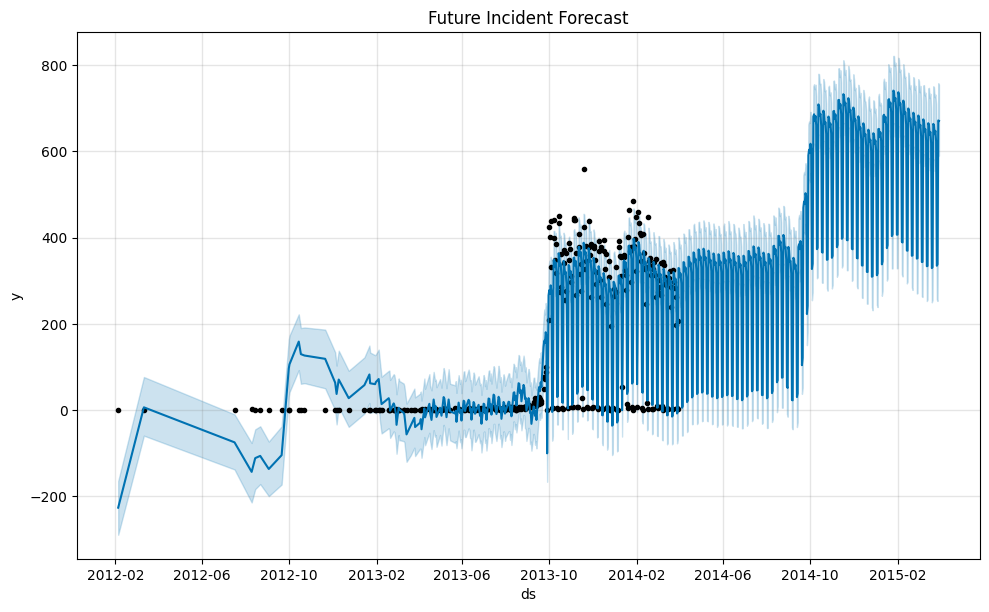

In [32]:
prophet_model.plot(forecast)

plt.title("Future Incident Forecast")

plt.show()

SEASONALITY ANALYSIS

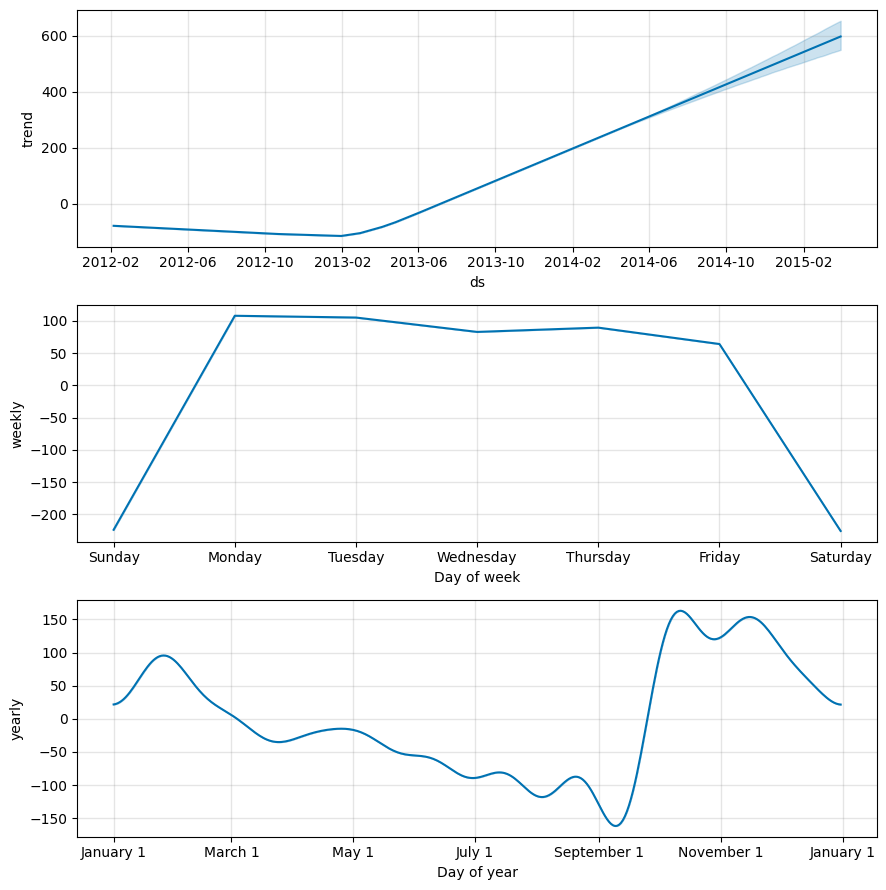

In [33]:
prophet_model.plot_components(forecast)

plt.show()


CREATE REPORT FOLDERS

In [34]:
import os

folders = [

    r"C:\Projects_Dm\ITSM_project\reports",

    r"C:\Projects_Dm\ITSM_project\reports\figures",

    r"C:\Projects_Dm\ITSM_project\models"

]

for folder in folders:

    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")

Folders created successfully


SAVE FORECAST CSV

In [35]:
forecast = prophet_model.predict(future)

In [36]:
forecast.to_csv(
    r"C:\Projects_Dm\ITSM_project\reports\forecast_output.csv",
    index=False
)

print("Forecast saved successfully")

Forecast saved successfully


SAVE COMPONENT GRAPH

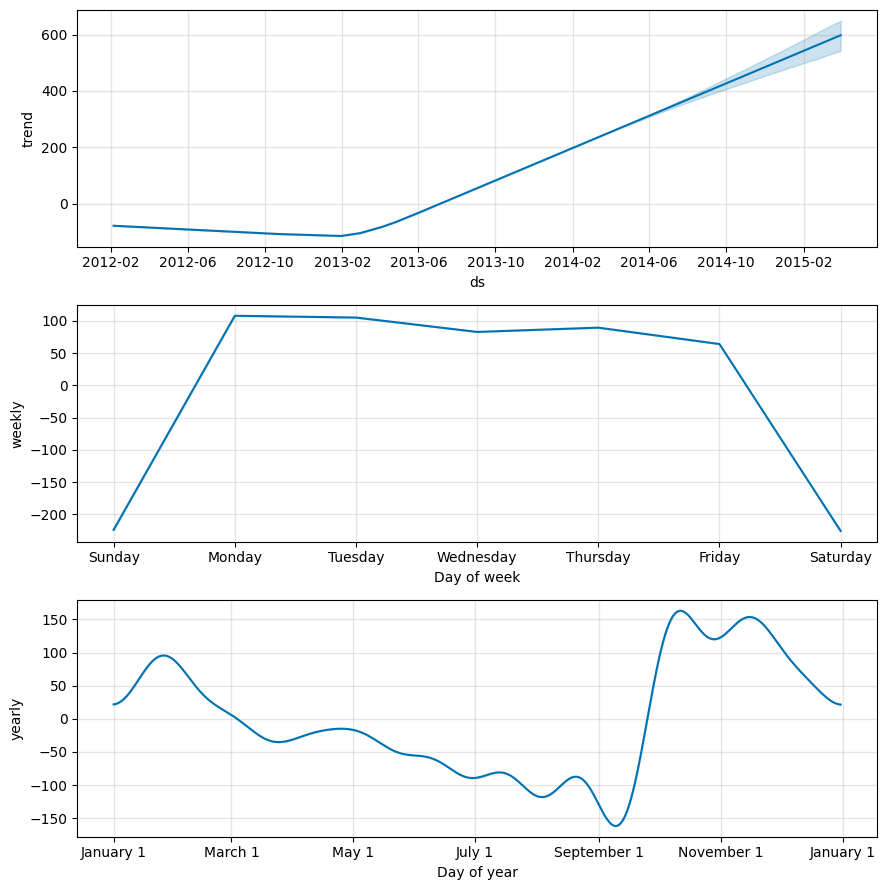

In [37]:
fig2 = prophet_model.plot_components(forecast)

fig2.savefig(
    r"C:\Projects_Dm\ITSM_project\reports\figures\seasonality_plot.png"
)

SAVE PROPHET MODEL

In [38]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import joblib

joblib.dump(
    prophet_model,
    r"C:\Projects_Dm\ITSM_project\models\forecast_model.pkl"
)

print("Forecast model saved successfully")

Forecast model saved successfully
